# Fit Dunst + Freund Models To Measured Lactate

This notebook fits, for each participant:
1. The Dunst-style exercise model (exercise phase).
2. The Freund/Durand recovery model (recovery phase).

The fitting is done directly on measured lactate values.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# File and timing configuration
XLS_FILE = "../DATA/Physio_Session2_Wingate.xlsx"
SHEET_NAME = "data"

START_TIME_S = 15
WINGATE_DURATION_S = 30
END_TIME_S = START_TIME_S + WINGATE_DURATION_S

# Dunst model constants
EXERCISE_DELAY_S = 2.0
EXERCISE_K3 = 0.18
EXERCISE_K4 = 0.06

# Default Freund parameters (used only as fallback)
DELTA_PEAK_DEFAULT = 10.0
GAMMA1_DEFAULT = 1 / 300
GAMMA2_DEFAULT = 1 / 2000

In [8]:
def to_abs_time_s(time_min):
    if time_min == -1:
        return START_TIME_S - 60
    return END_TIME_S + float(time_min) * 60.0


def dunst_delta(t_after_start_s, delta_end_target, delay_s=EXERCISE_DELAY_S, k3=EXERCISE_K3, k4=EXERCISE_K4):
    t_after_start_s = np.asarray(t_after_start_s, dtype=float)
    t_eff = np.clip(t_after_start_s - delay_s, 0.0, max(WINGATE_DURATION_S - delay_s, 0.0))

    g0 = -(1.0 / k3) + (1.0 / k4)
    g_end = (
        -(1.0 / k3) * np.exp(-k3 * max(WINGATE_DURATION_S - delay_s, 0.0))
        + (1.0 / k4) * np.exp(-k4 * max(WINGATE_DURATION_S - delay_s, 0.0))
    )
    denom = g_end - g0

    if np.isclose(denom, 0.0):
        return np.full_like(t_eff, float(delta_end_target), dtype=float)

    b_coef = float(delta_end_target) / denom
    c_coef = -b_coef * g0
    delta = b_coef * (
        -(1.0 / k3) * np.exp(-k3 * t_eff)
        + (1.0 / k4) * np.exp(-k4 * t_eff)
    ) + c_coef

    return np.maximum(delta, 0.0)


def dunst_lactate_abs(abs_t_s, la_base, delta_end_target):
    abs_t_s = np.asarray(abs_t_s, dtype=float)
    out = np.full_like(abs_t_s, float(la_base), dtype=float)

    exercise_mask = (abs_t_s >= START_TIME_S) & (abs_t_s <= END_TIME_S)
    if np.any(exercise_mask):
        t_after_start = abs_t_s[exercise_mask] - START_TIME_S
        out[exercise_mask] = float(la_base) + dunst_delta(t_after_start, delta_end_target)

    return out


def freund_recovery(t_after_rec_s, la_base, la_rec, delta_peak, gamma1, gamma2):
    t_after_rec_s = np.maximum(np.asarray(t_after_rec_s, dtype=float), 0.0)
    return (
        la_rec
        + (delta_peak + la_base - la_rec) * (1 - np.exp(-gamma1 * t_after_rec_s))
        + (-delta_peak) * (1 - np.exp(-gamma2 * t_after_rec_s))
    )


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)))

In [9]:
lac_all = pd.read_excel(XLS_FILE, sheet_name=SHEET_NAME)
lac_all.columns = [str(c).strip() for c in lac_all.columns]
lac_all["Time"] = pd.to_numeric(lac_all["Time"], errors="coerce")
lac_all["[La]"] = pd.to_numeric(lac_all["[La]"], errors="coerce")
lac_all = lac_all.dropna(subset=["Name", "Time", "[La]"]).copy()

participants = sorted(lac_all["Name"].astype(str).str.strip().unique().tolist())
print("Participants found:", participants)

Participants found: ['Alexis', 'Antoine', 'Enzo', 'Jinwei', 'Victor']


In [10]:
fit_rows = []
fit_curves = {}
fit_points = {}

for participant in participants:
    sub = lac_all[lac_all["Name"].astype(str).str.strip().str.lower() == participant.lower()].copy()
    sub = sub.sort_values("Time")

    base_row = sub[sub["Time"] == -1]
    rec0_row = sub[sub["Time"] == 0]

    if base_row.empty or rec0_row.empty:
        print(f"Skipping {participant}: missing baseline (-1) or handoff (0).")
        continue

    la_base = float(base_row["[La]"].iloc[0])
    la_rec = float(rec0_row["[La]"].iloc[0])

    # Exercise-phase fit with available exercise anchors (baseline and handoff).
    delta_end_fit = max(la_rec - la_base, 0.0)

    exercise_abs_t = np.array([START_TIME_S - 60, END_TIME_S], dtype=float)
    exercise_y_true = np.array([la_base, la_rec], dtype=float)
    exercise_y_pred = np.array([la_base, la_base + delta_end_fit], dtype=float)
    rmse_exercise = rmse(exercise_y_true, exercise_y_pred)

    # Recovery-phase fit on measured points after recovery onset (Time > 0).
    rec = sub[sub["Time"] > 0].copy()

    if len(rec) >= 3:
        t_rec_s = rec["Time"].to_numpy(float) * 60.0
        y_rec = rec["[La]"].to_numpy(float)

        delta_peak_init = max(float(np.max(y_rec) - la_base), 0.1)

        def recovery_for_fit(t, delta_peak, gamma1, gamma2):
            return freund_recovery(t, la_base, la_rec, delta_peak, gamma1, gamma2)

        try:
            p0 = [delta_peak_init, GAMMA1_DEFAULT, GAMMA2_DEFAULT]
            bounds = ([0.0, 1 / 10000, 1 / 10000], [40.0, 1 / 20, 1 / 20])
            popt, _ = curve_fit(recovery_for_fit, t_rec_s, y_rec, p0=p0, bounds=bounds, maxfev=50000)
            delta_peak_fit = float(popt[0])
            gamma1_fit = float(popt[1])
            gamma2_fit = float(popt[2])
        except Exception:
            delta_peak_fit = float(delta_peak_init)
            gamma1_fit = float(GAMMA1_DEFAULT)
            gamma2_fit = float(GAMMA2_DEFAULT)

        y_rec_pred = freund_recovery(t_rec_s, la_base, la_rec, delta_peak_fit, gamma1_fit, gamma2_fit)
        rmse_recovery = rmse(y_rec, y_rec_pred)
    else:
        delta_peak_fit = np.nan
        gamma1_fit = np.nan
        gamma2_fit = np.nan
        rmse_recovery = np.nan

    # Build fitted values at measured sampling times (full phase-aware model).
    measured_eval = sub[["Time", "[La]"]].copy()
    measured_eval["t_abs_s"] = measured_eval["Time"].apply(to_abs_time_s)

    y_fit_at_samples = []
    for _, rr in measured_eval.iterrows():
        t_abs = float(rr["t_abs_s"])

        if t_abs < START_TIME_S:
            y_hat = la_base
        elif t_abs <= END_TIME_S:
            y_hat = float(dunst_lactate_abs(np.array([t_abs]), la_base, delta_end_fit)[0])
        else:
            t_after_rec = t_abs - END_TIME_S
            if np.isfinite(delta_peak_fit) and np.isfinite(gamma1_fit) and np.isfinite(gamma2_fit):
                y_hat = float(freund_recovery(np.array([t_after_rec]), la_base, la_rec, delta_peak_fit, gamma1_fit, gamma2_fit)[0])
            else:
                y_hat = np.nan

        y_fit_at_samples.append(y_hat)

    measured_eval["La_fit"] = y_fit_at_samples

    valid_eval = measured_eval.dropna(subset=["La_fit"]).copy()
    rmse_all = rmse(valid_eval["[La]"], valid_eval["La_fit"]) if len(valid_eval) > 0 else np.nan
    mae_all = mae(valid_eval["[La]"], valid_eval["La_fit"]) if len(valid_eval) > 0 else np.nan

    # Continuous fitted curve for plotting.
    max_time_min = float(np.nanmax(sub["Time"])) if len(sub) > 0 else 12.0
    t_cont = np.arange(START_TIME_S - 60, END_TIME_S + max_time_min * 60.0 + 1, 1.0)

    la_cont = np.full_like(t_cont, la_base, dtype=float)

    mask_ex = (t_cont >= START_TIME_S) & (t_cont <= END_TIME_S)
    if np.any(mask_ex):
        la_cont[mask_ex] = dunst_lactate_abs(t_cont[mask_ex], la_base, delta_end_fit)

    mask_rec = t_cont > END_TIME_S
    if np.any(mask_rec) and np.isfinite(delta_peak_fit) and np.isfinite(gamma1_fit) and np.isfinite(gamma2_fit):
        la_cont[mask_rec] = freund_recovery(
            t_cont[mask_rec] - END_TIME_S,
            la_base,
            la_rec,
            delta_peak_fit,
            gamma1_fit,
            gamma2_fit,
        )

    fit_curves[participant] = pd.DataFrame({"Time_abs_s": t_cont, "La_fit": la_cont})
    fit_points[participant] = measured_eval.copy()

    fit_rows.append({
        "Participant": participant,
        "La_base": la_base,
        "La_recovery_onset": la_rec,
        "delta_end_exercise_fit": delta_end_fit,
        "k3_exercise": EXERCISE_K3,
        "k4_exercise": EXERCISE_K4,
        "delta_peak_recovery_fit": delta_peak_fit,
        "gamma1_recovery_fit": gamma1_fit,
        "gamma2_recovery_fit": gamma2_fit,
        "RMSE_exercise_anchor": rmse_exercise,
        "RMSE_recovery": rmse_recovery,
        "RMSE_all_points": rmse_all,
        "MAE_all_points": mae_all,
    })

fit_df = pd.DataFrame(fit_rows)
fit_df

,Participant,La_base,La_recovery_onset,delta_end_exercise_fit,k3_exercise,k4_exercise,delta_peak_recovery_fit,gamma1_recovery_fit,gamma2_recovery_fit,RMSE_exercise_anchor,RMSE_recovery,RMSE_all_points,MAE_all_points
0,Alexis,1.70,6.9,5.20,0.18,0.06,13.297034,0.035689,0.000292,0.0,0.881299,0.797165,0.553645
1,Antoine,2.20,11.5,9.30,0.18,0.06,14.525327,0.014237,0.000350,0.0,1.013390,0.916646,0.675703
2,Enzo,2.60,15.6,13.00,0.18,0.06,19.388527,0.050000,0.001238,0.0,1.547936,1.263884,1.027077
3,Jinwei,2.50,17.0,14.50,0.18,0.06,10.460691,0.050000,0.000188,0.0,1.133752,1.025517,0.732300
4,Victor,0.75,6.9,6.15,0.18,0.06,11.916079,0.013389,0.000100,0.0,0.824057,0.745387,0.598864


In [11]:
print("===== FITTED PARAMETERS (PER PARTICIPANT) =====")
display_cols = [
    "Participant",
    "La_base",
    "La_recovery_onset",
    "delta_end_exercise_fit",
    "delta_peak_recovery_fit",
    "gamma1_recovery_fit",
    "gamma2_recovery_fit",
    "RMSE_recovery",
    "RMSE_all_points",
    "MAE_all_points",
]
print(fit_df[display_cols])

if len(fit_df) > 0:
    pooled_rmse = float(np.sqrt(np.nanmean(fit_df["RMSE_all_points"] ** 2)))
    pooled_mae = float(np.nanmean(fit_df["MAE_all_points"]))
    print("\n===== OVERALL =====")
    print(f"Pooled RMSE across participants = {pooled_rmse:.3f} mmol/L")
    print(f"Mean MAE across participants   = {pooled_mae:.3f} mmol/L")

===== FITTED PARAMETERS (PER PARTICIPANT) =====
  Participant  La_base  La_recovery_onset  delta_end_exercise_fit  \
0      Alexis     1.70                6.9                    5.20   
1     Antoine     2.20               11.5                    9.30   
2        Enzo     2.60               15.6                   13.00   
3      Jinwei     2.50               17.0                   14.50   
4      Victor     0.75                6.9                    6.15   

   delta_peak_recovery_fit  gamma1_recovery_fit  gamma2_recovery_fit  \
0                13.297034             0.035689             0.000292   
1                14.525327             0.014237             0.000350   
2                19.388527             0.050000             0.001238   
3                10.460691             0.050000             0.000188   
4                11.916079             0.013389             0.000100   

   RMSE_recovery  RMSE_all_points  MAE_all_points  
0       0.881299         0.797165        0.553645  


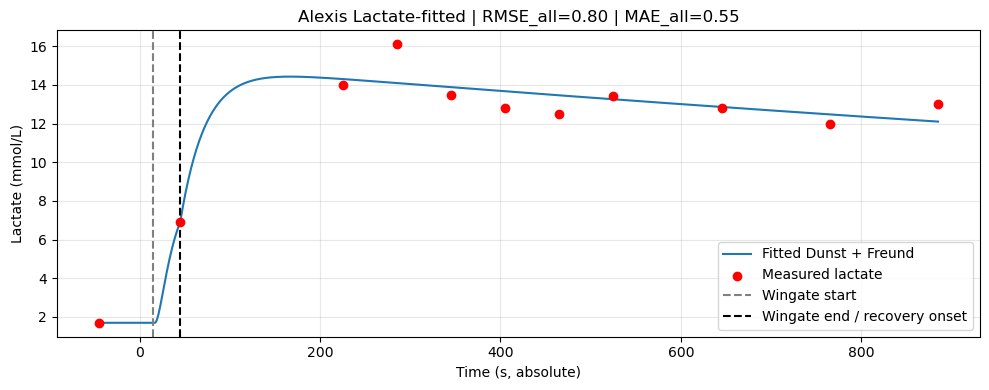

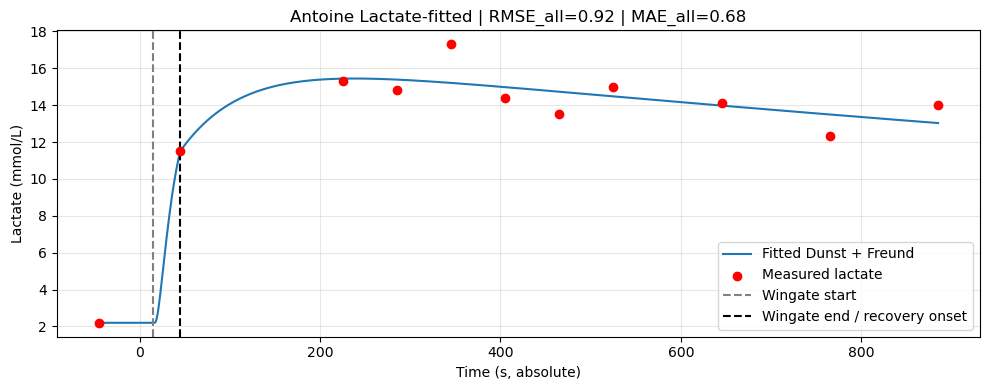

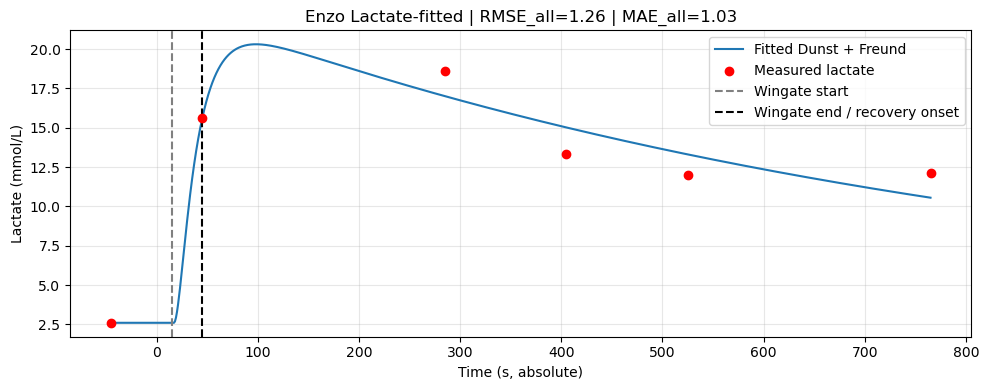

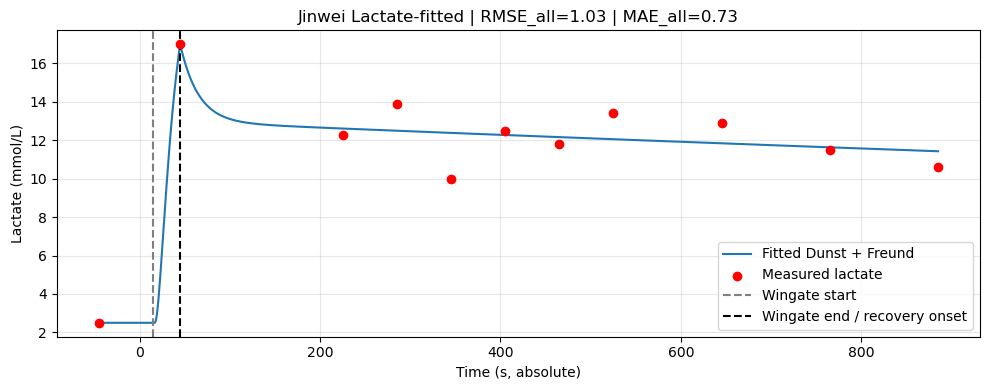

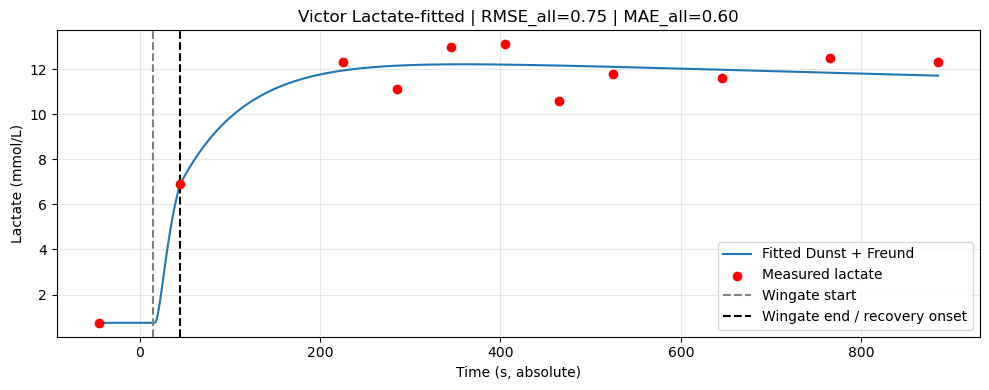

In [13]:
for participant in fit_df["Participant"].tolist():
    curve = fit_curves[participant]
    pts = fit_points[participant]

    plt.figure(figsize=(10, 4))
    plt.plot(curve["Time_abs_s"], curve["La_fit"], label="Fitted Dunst + Freund", color="tab:blue")
    plt.scatter(pts["t_abs_s"], pts["[La]"], color="red", label="Measured lactate", zorder=3)

    plt.axvline(START_TIME_S, linestyle="--", color="gray", label="Wingate start")
    plt.axvline(END_TIME_S, linestyle="--", color="black", label="Wingate end / recovery onset")

    row = fit_df[fit_df["Participant"] == participant].iloc[0]
    plt.title(
        f"{participant} Lactate-fitted | RMSE_all={row['RMSE_all_points']:.2f} | MAE_all={row['MAE_all_points']:.2f}"
    )
    plt.xlabel("Time (s, absolute)")
    plt.ylabel("Lactate (mmol/L)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()